# Clasificacion de Residuos - Red Neuronal Simple

**Proyecto:** Clasificacion Automatica de Residuos mediante Deep Learning  
**Asignatura:** Aprendizaje Profundo  
**Entrega 3:** Modelo de red neuronal simple  

---

## Objetivos del Notebook

1. **Cargar** el dataset preprocesado y verificar su consistencia.
2. **Dividir** el conjunto en train/validacion/test de forma estratificada.
3. **Definir** un modelo CNN minimo (capas convolucionales = numero de clases).
4. **Entrenar** el modelo y mostrar curvas de entrenamiento.
5. **Evaluar** el rendimiento en train, validacion y test.
6. **Reportar** el numero de parametros del modelo.

In [ ]:
# ========================================
# 1. IMPORTS Y CONFIGURACION
# ========================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import keras

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Agregar ruta del proyecto al path (carpeta padre de notebooks)
sys.path.insert(0, '..')

# Importar funciones de utilidad
from src.utils import initialize_project

2026-02-27 09:44:42.378665: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 09:44:42.378869: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 09:44:42.405277: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 09:44:43.082232: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

## 2. Carga de datos y configuración

Se carga automáticamente el dataset desde el archivo .npz y se realiza la división estratificada.

In [4]:
# ========================================
# 2. CARGA DE DATOS Y CONFIGURACION
# ========================================

X_train, y_train, X_val, y_val, X_test, y_test, class_names = initialize_project()

Ejecutando en local

Cargando datos desde: /home/anuega/archivos/notebooks/../data/processed/trashnet_224x224.npz
  X.shape: (2527, 224, 224, 3)
  y.shape: (2527,)
  Clases: cardboard, glass, metal, paper, plastic, trash

División estratificada (seed=44):
  Train: 1768 imágenes (70%)
  Val:   379 imágenes (15%)
  Test:  380 imágenes (15%)


## 3. Definición del modelo

El modelo se define en `models/simple_cnn.py` y se carga desde el notebook.

La red es una **CNN mínima para clasificación multiclase**. Incluye una única capa Conv2D con tantos filtros como clases, de modo que cada filtro aprende un mapa de activación asociado a patrones discriminativos de una clase. La capa GlobalAveragePooling2D promedia cada mapa espacialmente, reduciéndolo a un único valor por clase. Finalmente, una capa densa con activación softmax produce una distribución de probabilidad sobre las clases.

En el entrenamiento se **minimiza la sparse categorical cross-entropy**, adecuada cuando las etiquetas están codificadas como enteros. Esta función mide la discrepancia entre la distribución predicha por la softmax y la clase verdadera. La optimización se realiza con Adam (learning rate 1e-3).

In [5]:
# ========================================
# 3. CARGA DEL MODELO DESDE MODELS
# ========================================

models_dir = Path('../models').resolve()
if str(models_dir) not in sys.path:
    sys.path.append(str(models_dir))

from simple_cnn import build_simple_cnn

input_shape = X_train.shape[1:]
num_classes = len(class_names)

model = build_simple_cnn(input_shape=input_shape, num_classes=num_classes)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
 )

model.summary()

/home/anuega/miniconda3/envs/gcd/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.

E0000 00:00:1772181887.891121  949954 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772181887.897782  949954 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210 (840.00 B)

 Trainable params: 210 (840.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento

Se entrena el modelo y se muestran las curvas de loss y accuracy.

In [6]:
# ========================================
# 4. ENTRENAMIENTO
# ========================================

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
 )

Epoch 1/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1657 - loss: 29.2400 - val_accuracy: 0.2243 - val_loss: 16.3899 - learning_rate: 0.0010
Epoch 2/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1748 - loss: 12.0116 - val_accuracy: 0.1636 - val_loss: 7.3544 - learning_rate: 0.0010
Epoch 3/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2217 - loss: 3.8792 - val_accuracy: 0.2164 - val_loss: 2.2506 - learning_rate: 0.0010
Epoch 4/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2296 - loss: 2.0870 - val_accuracy: 0.2586 - val_loss: 2.0211 - learning_rate: 0.0010
Epoch 5/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2568 - loss: 1.9628 - val_accuracy: 0.2586 - val_loss: 1.9404 - learning_rate: 0.0010
Epoch 6/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2523 - loss: 1.8984 - val_accuracy: 0.2480 - val_loss: 1.8859 - learning_rate: 0.0010
Epoch 7/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2557 - loss: 1.8522 - val_

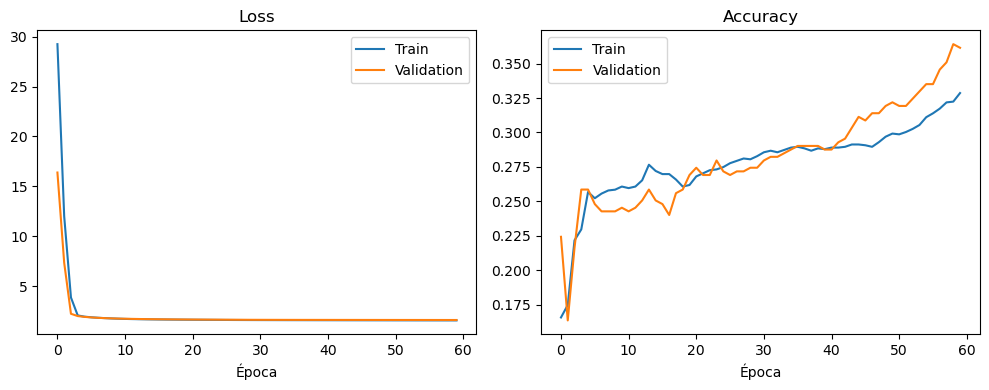

In [9]:
plt.figure(figsize=(10,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Época")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Época")
plt.legend()

plt.tight_layout()
plt.show()

## 5. Evaluación en particiones

Se evalúa el modelo en train, validación y test con métricas estándar.

In [10]:
def evaluate_model(model, X, y, split_name):
    probs = model.predict(X, batch_size=32, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    acc = accuracy_score(y, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y, y_pred,
        average='macro',
        zero_division=0
    )

    print(f"\nResultados en {split_name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y, y_pred,
        target_names=class_names,
        zero_division=0
    ))

    return acc, prec, rec, f1, y_pred

In [11]:
results_train = evaluate_model(model, X_train, y_train, 'TRAIN')
results_val = evaluate_model(model, X_val, y_val, 'VALIDACION')
results_test = evaluate_model(model, X_test, y_test, 'TEST')

# Resumen comparativo
print("\nResumen comparativo de métricas:")
print(f"{'Partición':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"{'-'*12} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
print(f"{'Train':<12} {results_train[0]:>10.4f} {results_train[1]:>10.4f} {results_train[2]:>10.4f} {results_train[3]:>10.4f}")
print(f"{'Validación':<12} {results_val[0]:>10.4f} {results_val[1]:>10.4f} {results_val[2]:>10.4f} {results_val[3]:>10.4f}")
print(f"{'Test':<12} {results_test[0]:>10.4f} {results_test[1]:>10.4f} {results_test[2]:>10.4f} {results_test[3]:>10.4f}")


Resultados en TRAIN:
  Accuracy:  0.3535
  Precision: 0.3688
  Recall:    0.2863
  F1-score:  0.2467

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.38      0.07      0.12       282
       glass       0.26      0.49      0.33       350
       metal       0.70      0.02      0.05       287
       paper       0.35      0.57      0.43       416
     plastic       0.52      0.57      0.54       337
       trash       0.00      0.00      0.00        96

    accuracy                           0.35      1768
   macro avg       0.37      0.29      0.25      1768
weighted avg       0.41      0.35      0.30      1768


Resultados en VALIDACION:
  Accuracy:  0.3615
  Precision: 0.3435
  Recall:    0.2927
  F1-score:  0.2508

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.42      0.08      0.14        61
       glass       0.31      0.51      0.38        75
       metal       0.50      0.02    

### 5.1. Visualización de métricas

Comparación visual de las métricas entre las particiones para identificar posible overfitting o underfitting.

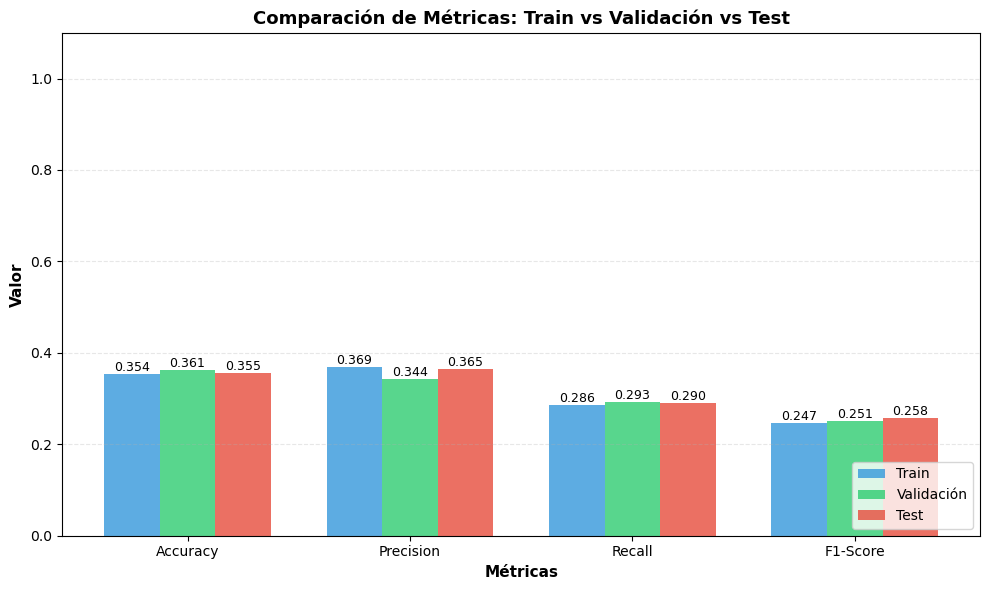


Análisis de generalización:
  Diferencia Accuracy (Train - Test): -0.0018
  Excelente generalización - No hay overfitting significativo


In [12]:
# Visualización comparativa de métricas
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_metrics = list(results_train[:4])
val_metrics = list(results_val[:4])
test_metrics = list(results_test[:4])

x = np.arange(len(metrics_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, train_metrics, width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, val_metrics, width, label='Validación', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, test_metrics, width, label='Test', color='#e74c3c', alpha=0.8)

# Etiquetas en las barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Métricas', fontweight='bold', fontsize=11)
ax.set_ylabel('Valor', fontweight='bold', fontsize=11)
ax.set_title('Comparación de Métricas: Train vs Validación vs Test', 
             fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Análisis de generalización
diff_train_test = results_train[0] - results_test[0]
print(f"\nAnálisis de generalización:")
print(f"  Diferencia Accuracy (Train - Test): {diff_train_test:.4f}")
if diff_train_test < 0.05:
    print("  Excelente generalización - No hay overfitting significativo")
elif diff_train_test < 0.10:
    print("  Buena generalización - Overfitting leve")
elif diff_train_test < 0.15:
    print("  Generalización moderada - Overfitting presente")
else:
    print("  Poca generalización - Overfitting severo")

### 5.2. Matrices de confusión

Visualización de las matrices de confusión para cada partición (train, validación y test) para identificar patrones de error.

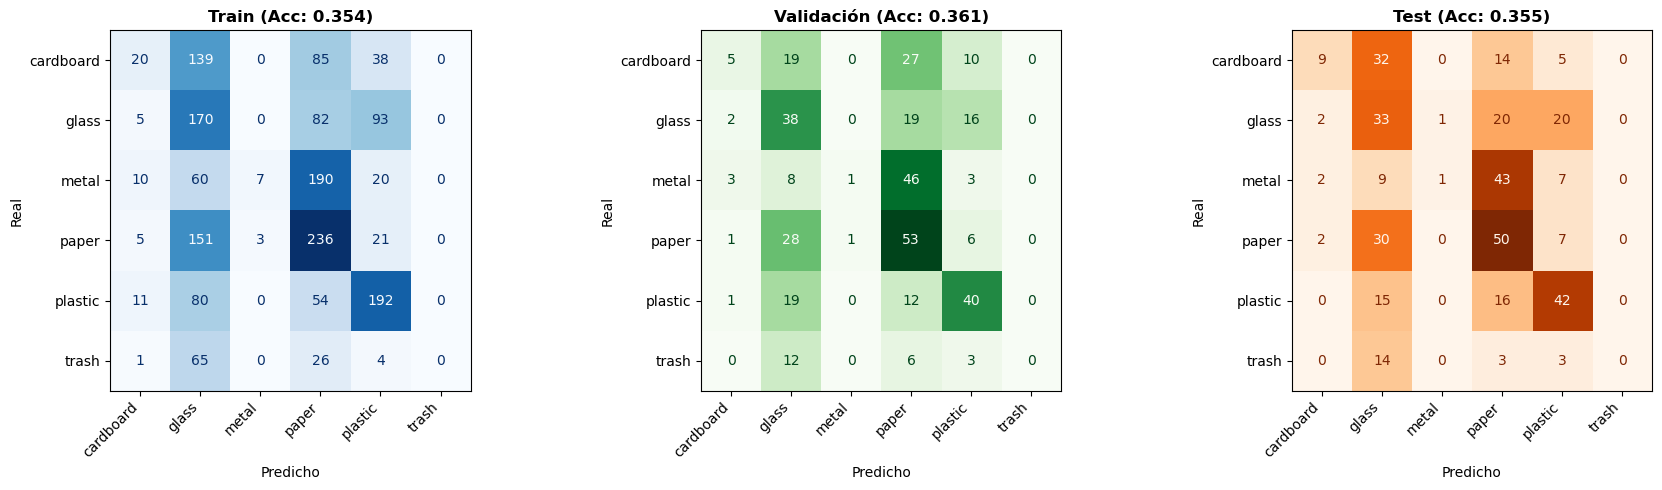

In [13]:
# Matrices de confusión para Train, Val y Test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicciones
y_pred_train = results_train[4]
y_pred_val = results_val[4]
y_pred_test = results_test[4]

# Train
cm_train = confusion_matrix(y_train, y_pred_train)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=class_names)
disp_train.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Train (Acc: {results_train[0]:.3f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Predicho", fontsize=10)
axes[0].set_ylabel("Real", fontsize=10)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Validación
cm_val = confusion_matrix(y_val, y_pred_val)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=class_names)
disp_val.plot(ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Validación (Acc: {results_val[0]:.3f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Predicho", fontsize=10)
axes[1].set_ylabel("Real", fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Test
cm_test = confusion_matrix(y_test, y_pred_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot(ax=axes[2], cmap="Oranges", colorbar=False)
axes[2].set_title(f"Test (Acc: {results_test[0]:.3f})", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Predicho", fontsize=10)
axes[2].set_ylabel("Real", fontsize=10)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## 6. Interpretabilidad
 A diferencia del SVM que usa márgenes geométricos, en una Red Neuronal analizamos la **probabilidad softmax** 
 - **Alta confianza:** La probabilidad de la clase ganadora es cercana a 1.0 (ej: 0.99 vs 0.01).
 - **Incertidumbre (Duda):** La probabilidad se reparte entre varias clases.

 Aquí buscamos las imágenes con el menor **"Confidence Gap"**: la diferencia entre la probabilidad de la clase ganadora y la de la segunda mejor opción.

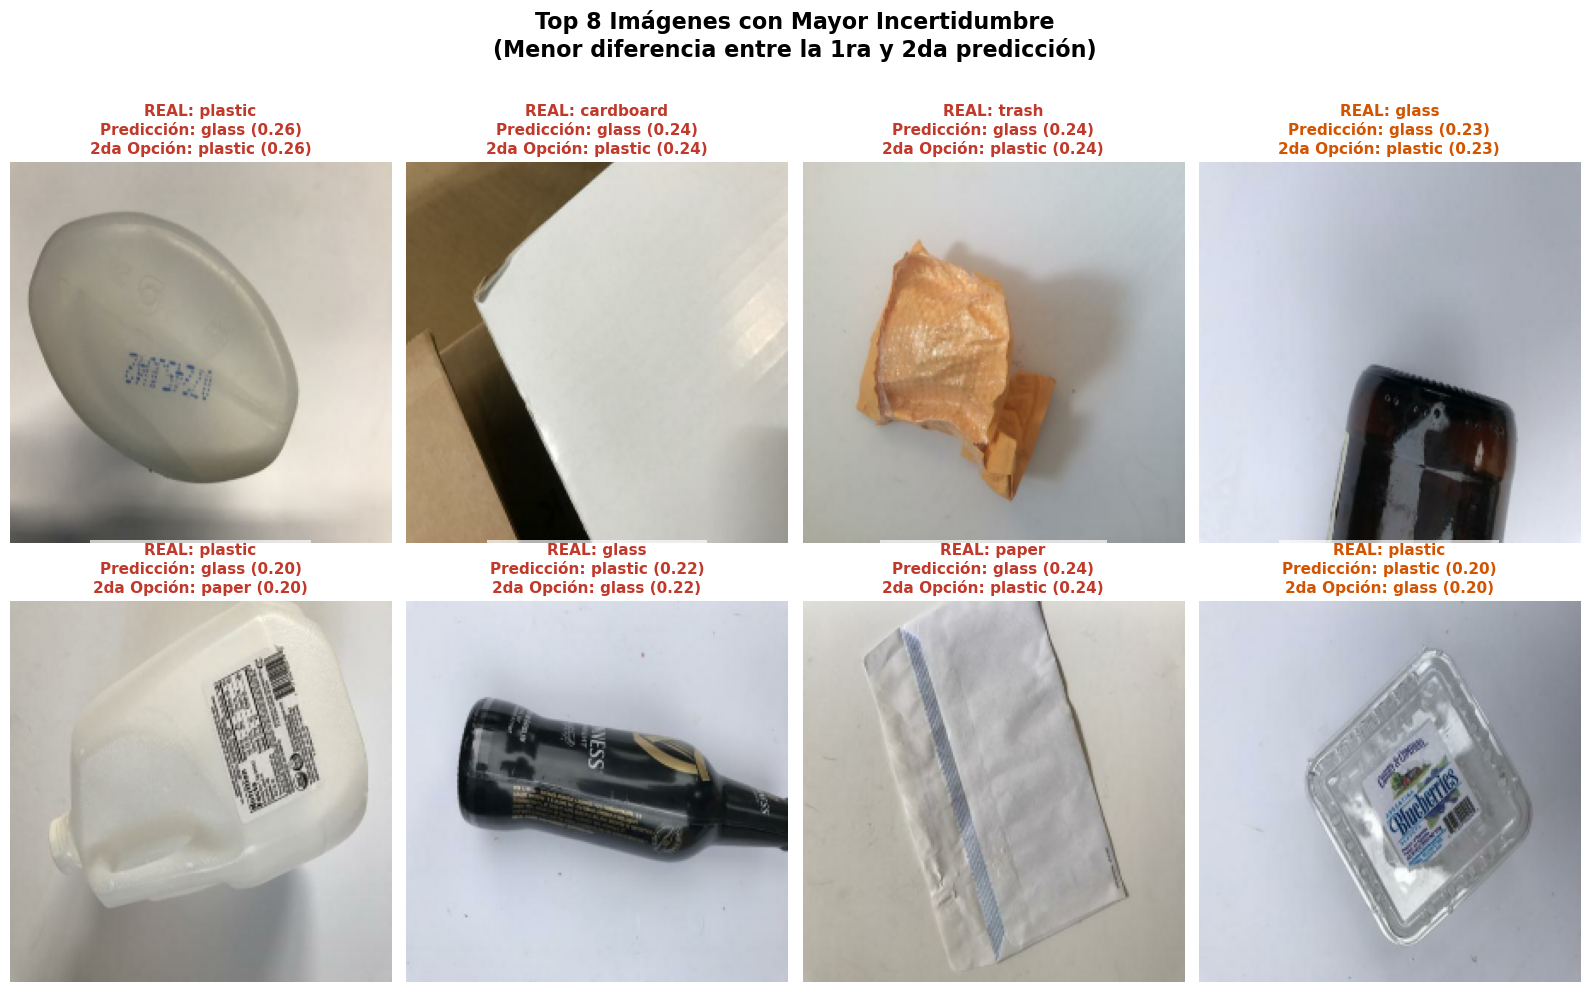

In [14]:
# 1. Obtener probabilidades
probs_test = model.predict(X_test, verbose=0)

# 2. Obtener los índices de las clases ordenados por probabilidad
top_indices_sorted = np.argsort(probs_test, axis=1)

# 3. Calcular la diferencia (gap) entre la 1ra y 2da opción
sorted_probs = np.sort(probs_test, axis=1)
uncertainty_gap = sorted_probs[:, -1] - sorted_probs[:, -2]

# 4. Seleccionar los índices de las imágenes con mayor duda (menor gap)
k = 8
most_uncertain_idx = np.argsort(uncertainty_gap)[:k]

# 5. Visualización
cols = 4
rows = int(np.ceil(k / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows)) # Un poco más alto para el texto
axes = np.array(axes).reshape(-1)

# --- TÍTULO GENERAL DE LA FIGURA ---
plt.suptitle(f"Top {k} Imágenes con Mayor Incertidumbre\n(Menor diferencia entre la 1ra y 2da predicción)", 
             fontsize=16, fontweight='bold', y=1.02)

for i, (ax, idx) in enumerate(zip(axes, most_uncertain_idx)):
    img = X_test[idx].astype(np.uint8)
    
    # Índices reales y predichos
    true_idx = y_test[idx]
    pred_idx_1 = top_indices_sorted[idx, -1] # La más alta
    pred_idx_2 = top_indices_sorted[idx, -2] # La segunda más alta
    
    # Nombres
    true_lbl = class_names[true_idx]
    pred_lbl_1 = class_names[pred_idx_1]
    pred_lbl_2 = class_names[pred_idx_2]
    
    # Probabilidades
    prob_1 = sorted_probs[idx, -1]
    prob_2 = sorted_probs[idx, -2]
    
    # Color: Rojo si falló, Naranja si acertó pero dudando
    color_text = '#c0392b' if true_idx != pred_idx_1 else '#d35400'
    
    ax.imshow(img)
    
    # --- TÍTULO DETALLADO POR IMAGEN ---
    info_text = (
        f"REAL: {true_lbl}\n"
        f"Predicción: {pred_lbl_1} ({prob_1:.2f})\n"
        f"2da Opción: {pred_lbl_2} ({prob_2:.2f})"
    )
    
    ax.set_title(info_text, fontsize=11, fontweight='bold', color=color_text,  bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
    ax.axis('off')

# Apagar ejes vacíos
for ax in axes[k:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

### 6.2. Visualización de Errores en Test

Muestra ejemplos concretos de imágenes del conjunto de Test que el modelo clasificó incorrectamente para entender las debilidades del clasificador.

Resumen de errores en Test:
  Total muestras: 380
  Errores: 245 (64.47%)


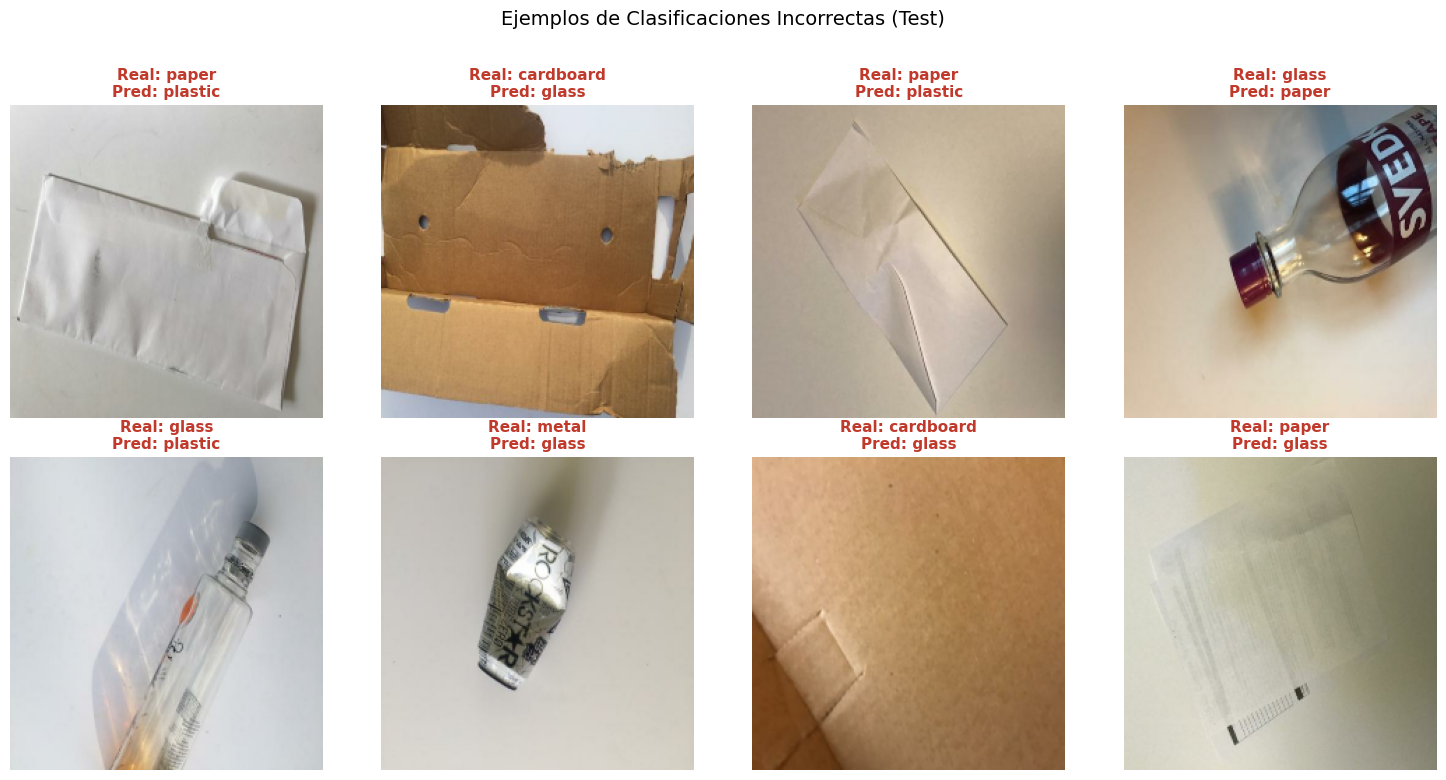


Confusiones más frecuentes (Real -> Predicho):
  metal        -> paper        : 43 veces
  cardboard    -> glass        : 32 veces
  paper        -> glass        : 30 veces
  glass        -> plastic      : 20 veces
  glass        -> paper        : 20 veces


In [15]:
# =======================================
# 6.2. VISUALIZACION DE ERRORES
# ========================================

# Identificar índices de errores
mis_idx = np.where(y_pred_test != y_test)[0]
total_test = len(y_test)
num_errors = len(mis_idx)

print(f"Resumen de errores en Test:")
print(f"  Total muestras: {total_test}")
print(f"  Errores: {num_errors} ({num_errors/total_test*100:.2f}%)")

if num_errors > 0:
    # Mostrar hasta 8 ejemplos de error aleatorios
    show_n = min(8, num_errors)
    
    np.random.seed(42) 
    chosen_errors = np.random.choice(mis_idx, size=show_n, replace=False)
    
    cols = 4
    rows = int(np.ceil(show_n / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.8 * rows))
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, idx) in enumerate(zip(axes, chosen_errors)):
        img = X_test[idx].astype(np.uint8)
        true_lbl = class_names[y_test[idx]]
        pred_lbl = class_names[y_pred_test[idx]]
        
        ax.imshow(img)
        # Título en rojo indicando el error
        ax.set_title(f"Real: {true_lbl}\nPred: {pred_lbl}", 
                     color='#c0392b', fontsize=11, fontweight='bold')
        ax.axis('off')
        
    # Ocultar ejes vacíos si hay menos de 8 errores
    for ax in axes[show_n:]:
        ax.axis('off')
        
    plt.suptitle("Ejemplos de Clasificaciones Incorrectas (Test)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Mostrar pares de confusión más frecuentes
    print("\nConfusiones más frecuentes (Real -> Predicho):")
    error_pairs = [(class_names[y_test[i]], class_names[y_pred_test[i]]) for i in mis_idx]
    from collections import Counter
    most_common = Counter(error_pairs).most_common(5)
    
    for (real, pred), count in most_common:
        print(f"  {real:12} -> {pred:12} : {count} veces")

## 7. Número de parámetros del modelo

Se reporta el número total de parámetros entrenables del modelo.

In [16]:
num_params = model.count_params()
print(f'Número total de parámetros: {num_params:,}')

Número total de parámetros: 210


## 8. Resumen final

Resumen compacto con las métricas del modelo.

In [17]:
print('\nRESUMEN FINAL (CNN SIMPLE)')
print(f'  Train -> Acc: {results_train[0]:.4f}, F1: {results_train[3]:.4f}')
print(f'  Val   -> Acc: {results_val[0]:.4f}, F1: {results_val[3]:.4f}')
print(f'  Test  -> Acc: {results_test[0]:.4f}, F1: {results_test[3]:.4f}')
print(f'  Params: {num_params:,}')


RESUMEN FINAL (CNN SIMPLE)
  Train -> Acc: 0.3535, F1: 0.2467
  Val   -> Acc: 0.3615, F1: 0.2508
  Test  -> Acc: 0.3553, F1: 0.2579
  Params: 210
